In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

print("Libraries ready! Let's analyze IPL data.")

Libraries ready! Let's analyze IPL data.


In [2]:
np.random.seed(10)

teams = ['MI','CSK','RCB','KKR','DC','SRH','PBKS','RR','LSG','GT']
players = {
    'MI':   ['Rohit Sharma','Hardik Pandya','Suryakumar Yadav','Jasprit Bumrah','Kieron Pollard'],
    'CSK':  ['MS Dhoni','Ruturaj Gaikwad','Devon Conway','Deepak Chahar','Ravindra Jadeja'],
    'RCB':  ['Virat Kohli','Faf du Plessis','Glenn Maxwell','Mohammed Siraj','Dinesh Karthik'],
    'KKR':  ['Shreyas Iyer','Sunil Narine','Andre Russell','Varun Chakravarthy','Nitish Rana'],
    'DC':   ['Rishabh Pant','David Warner','Mitchell Marsh','Anrich Nortje','Axar Patel'],
    'SRH':  ['Kane Williamson','Bhuvneshwar Kumar','T Natarajan','Abhishek Sharma','Heinrich Klaasen'],
    'PBKS': ['Shikhar Dhawan','Liam Livingstone','Kagiso Rabada','Sam Curran','Jonny Bairstow'],
    'RR':   ['Sanju Samson','Jos Buttler','Yuzvendra Chahal','Trent Boult','Shimron Hetmyer'],
    'LSG':  ['KL Rahul','Quinton de Kock','Ravi Bishnoi','Mark Wood','Nicholas Pooran'],
    'GT':   ['Shubman Gill','Hardik Pandya','Mohammed Shami','Rashid Khan','David Miller'],
}
seasons = list(range(2008, 2024))

batting_rows = []
for season in seasons:
    for team, plist in players.items():
        for player in plist:
            matches  = np.random.randint(8, 17)
            runs     = np.random.randint(80, 650)
            balls    = int(runs / np.random.uniform(1.1, 2.2))
            fours    = np.random.randint(5, 40)
            sixes    = np.random.randint(2, 30)
            fifties  = np.random.randint(0, 5)
            hundreds = np.random.randint(0, 2)
            batting_rows.append({
                'Season': season, 'Team': team, 'Player': player,
                'Matches': matches, 'Runs': runs, 'Balls': balls,
                'Fours': fours, 'Sixes': sixes,
                'Fifties': fifties, 'Hundreds': hundreds,
                'Strike Rate': round(runs/balls*100, 2),
                'Average': round(runs/max(matches-np.random.randint(0,3),1), 2)
            })

batting = pd.DataFrame(batting_rows)

bowling_rows = []
for season in seasons:
    for team, plist in players.items():
        for player in plist:
            matches  = np.random.randint(8, 17)
            wickets  = np.random.randint(0, 25)
            runs_given = np.random.randint(100, 500)
            overs    = np.random.uniform(20, 60)
            bowling_rows.append({
                'Season': season, 'Team': team, 'Player': player,
                'Matches': matches, 'Wickets': wickets,
                'Runs Given': runs_given, 'Overs': round(overs,1),
                'Economy': round(runs_given/overs, 2),
                'Average': round(runs_given/max(wickets,1), 2)
            })

bowling = pd.DataFrame(bowling_rows)
print(f"Batting dataset: {batting.shape}")
print(f"Bowling dataset: {bowling.shape}")
batting.head()

Batting dataset: (800, 12)
Bowling dataset: (800, 9)


,Season,Team,Player,Matches,Runs,Balls,Fours,Sixes,Fifties,Hundreds,Strike Rate,Average
0,2008,MI,Rohit Sharma,12,607,337,33,27,0,1,180.12,55.18
1,2008,MI,Hardik Pandya,16,153,118,21,6,3,0,129.66,9.56
2,2008,MI,Suryakumar Yadav,9,280,135,18,7,3,1,207.41,40.00
3,2008,MI,Jasprit Bumrah,14,169,107,36,27,4,1,157.94,14.08
4,2008,MI,Kieron Pollard,14,475,226,29,11,2,0,210.18,39.58


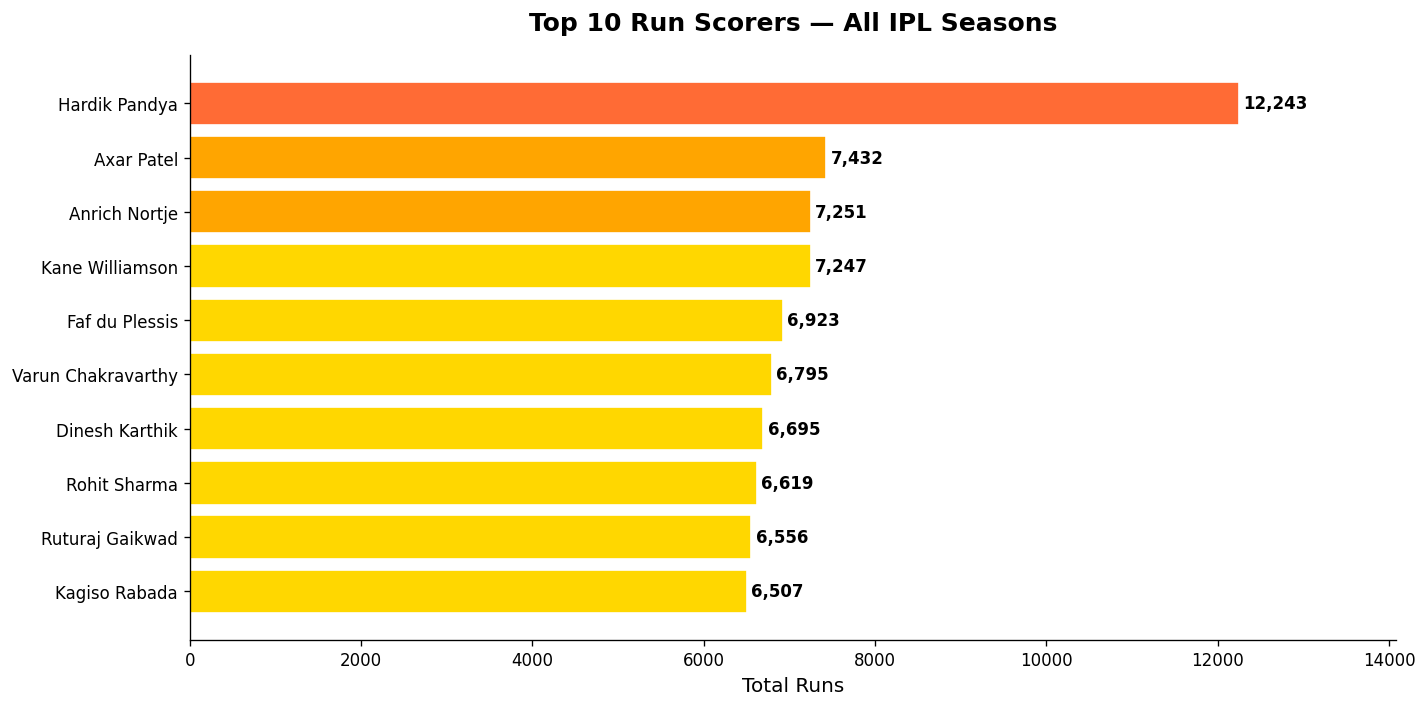

In [3]:
top_batters = (batting.groupby('Player')['Runs']
               .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#FF6B35' if i == 0 else '#FFA500' if i < 3 else '#FFD700'
          for i in range(len(top_batters))]
bars = ax.barh(top_batters.index, top_batters.values, color=colors, edgecolor='white')

for bar, val in zip(bars, top_batters.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Total Runs', fontsize=12)
ax.set_title('Top 10 Run Scorers — All IPL Seasons', fontsize=15, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.set_xlim(0, top_batters.max() * 1.15)
plt.tight_layout()
plt.savefig('ipl_top_batters.png', dpi=150, bbox_inches='tight')
plt.show()

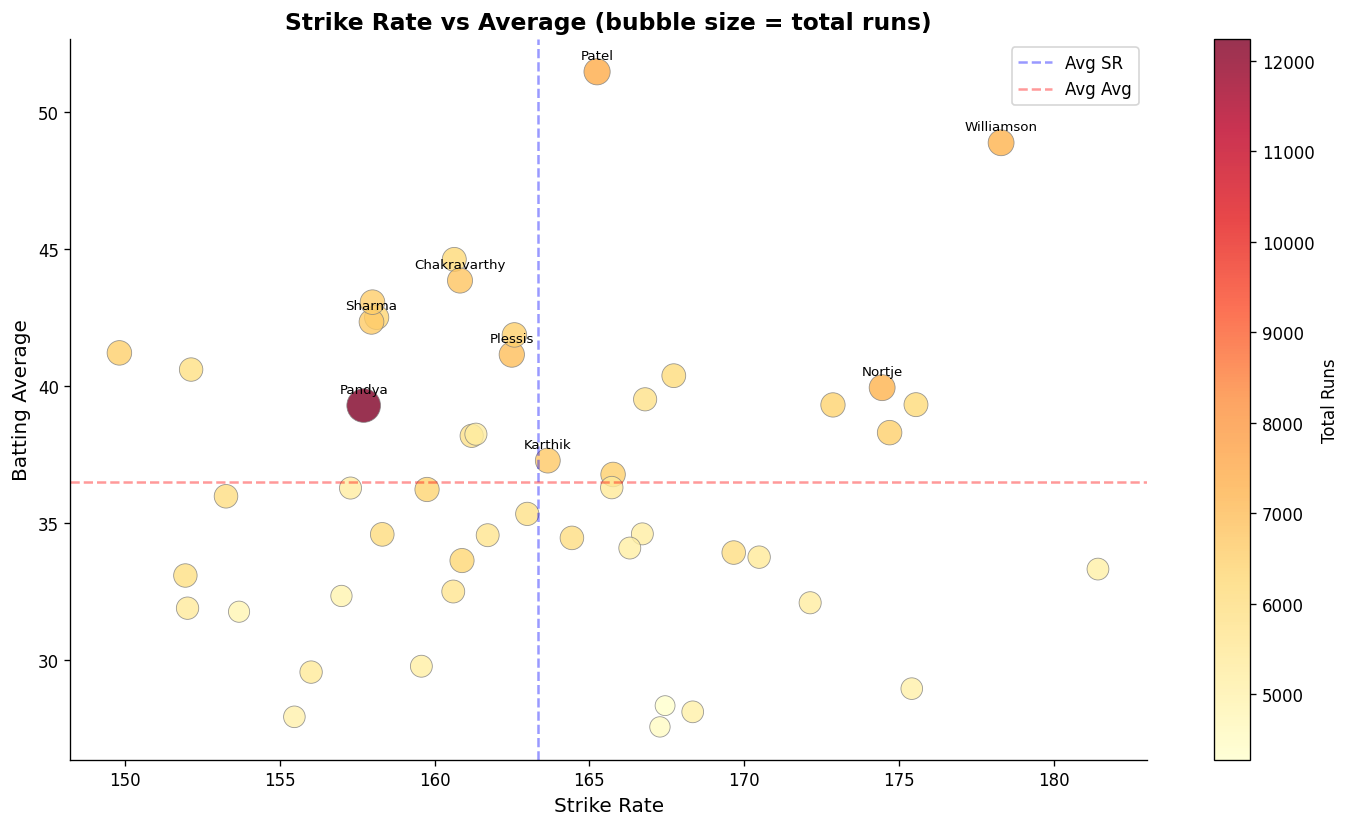

In [4]:
batter_agg = batting.groupby('Player').agg(
    Total_Runs = ('Runs','sum'),
    Avg_SR     = ('Strike Rate','mean'),
    Avg_Avg    = ('Average','mean')
).reset_index()
batter_agg = batter_agg[batter_agg['Total_Runs'] > 1000]

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(batter_agg['Avg_SR'], batter_agg['Avg_Avg'],
                     c=batter_agg['Total_Runs'], cmap='YlOrRd',
                     s=batter_agg['Total_Runs']/30, alpha=0.8, edgecolors='gray', lw=0.5)

for _, row in batter_agg.nlargest(8,'Total_Runs').iterrows():
    ax.annotate(row['Player'].split()[-1],
                (row['Avg_SR'], row['Avg_Avg']),
                fontsize=8, ha='center', va='bottom',
                xytext=(0,6), textcoords='offset points')

plt.colorbar(scatter, label='Total Runs')
ax.axvline(batter_agg['Avg_SR'].mean(), color='blue', linestyle='--', alpha=0.4, label='Avg SR')
ax.axhline(batter_agg['Avg_Avg'].mean(), color='red',  linestyle='--', alpha=0.4, label='Avg Avg')
ax.set_xlabel('Strike Rate', fontsize=12)
ax.set_ylabel('Batting Average', fontsize=12)
ax.set_title('Strike Rate vs Average (bubble size = total runs)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('ipl_sr_vs_avg.png', dpi=150, bbox_inches='tight')
plt.show()

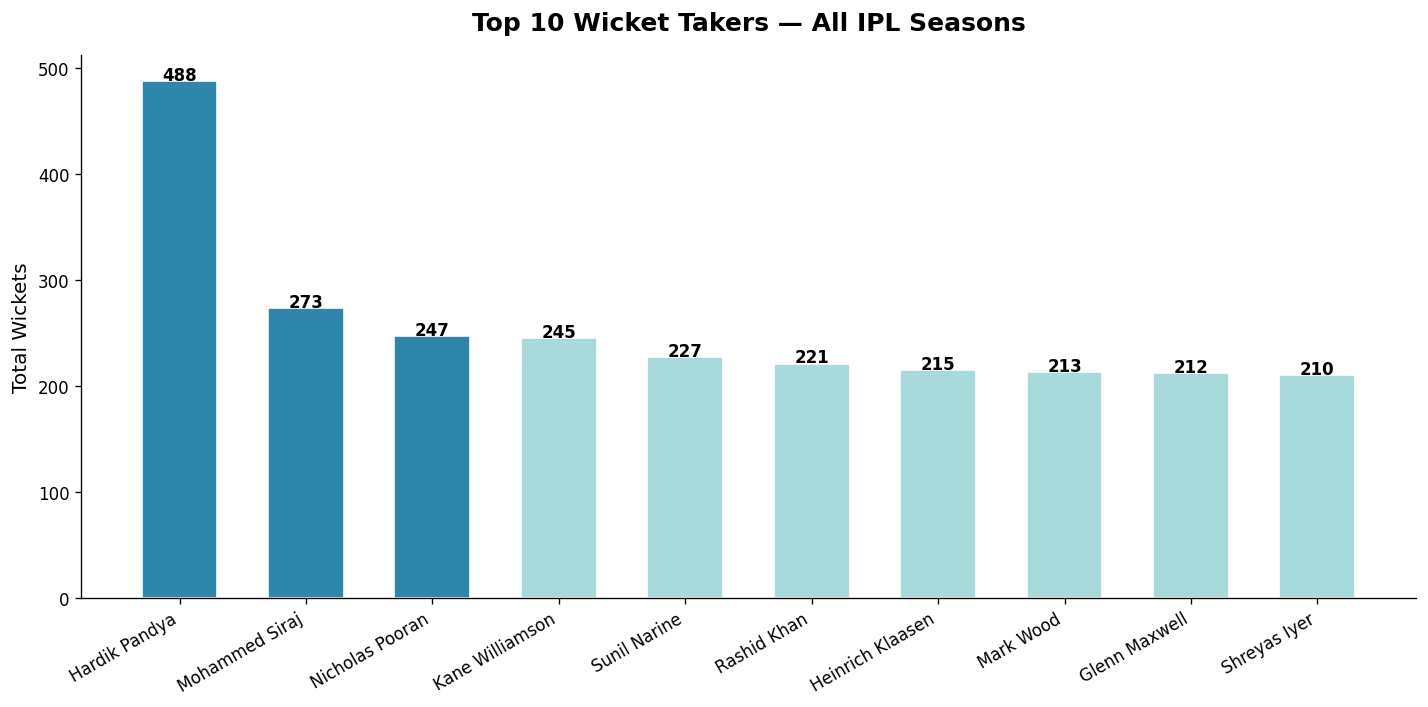

In [5]:
top_bowlers = (bowling.groupby('Player')['Wickets']
               .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ['#2E86AB' if i < 3 else '#A8DADC' for i in range(len(top_bowlers))]
bars = ax.bar(top_bowlers.index, top_bowlers.values,
              color=bar_colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, top_bowlers.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Total Wickets', fontsize=12)
ax.set_title('Top 10 Wicket Takers — All IPL Seasons', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('ipl_top_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()


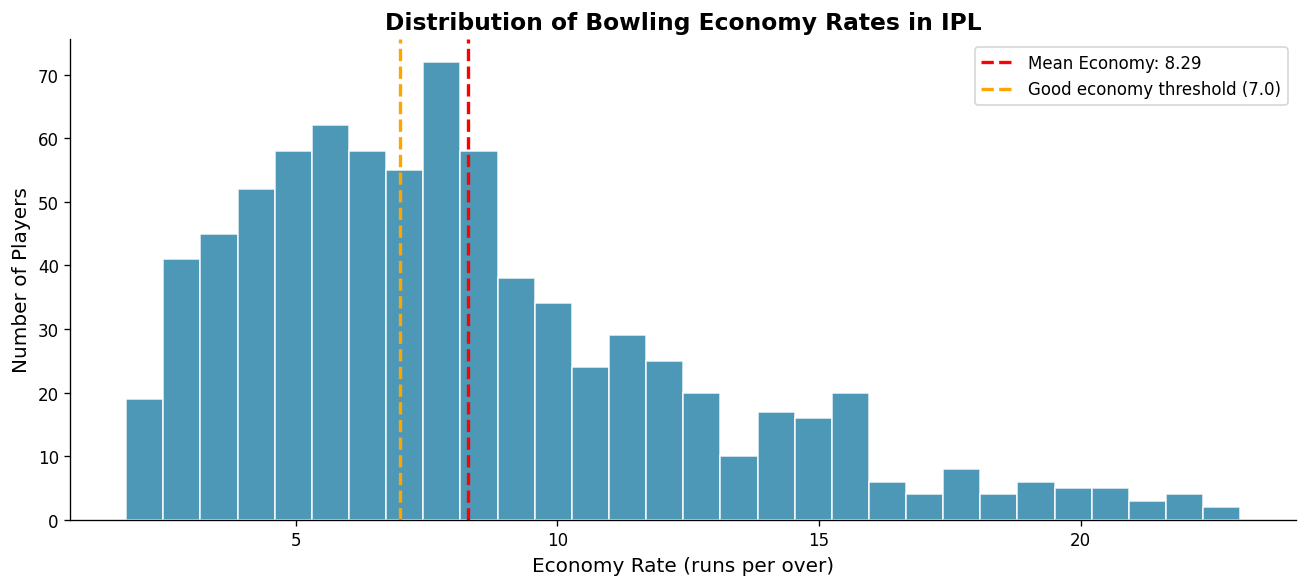

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(bowling['Economy'], bins=30, color='#2E86AB',
        edgecolor='white', alpha=0.85)

mean_eco = bowling['Economy'].mean()
ax.axvline(mean_eco, color='red', linestyle='--', linewidth=2,
           label=f'Mean Economy: {mean_eco:.2f}')
ax.axvline(7.0, color='orange', linestyle='--', linewidth=2,
           label='Good economy threshold (7.0)')

ax.set_xlabel('Economy Rate (runs per over)', fontsize=12)
ax.set_ylabel('Number of Players', fontsize=12)
ax.set_title('Distribution of Bowling Economy Rates in IPL', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('ipl_economy_dist.png', dpi=150, bbox_inches='tight')
plt.show()

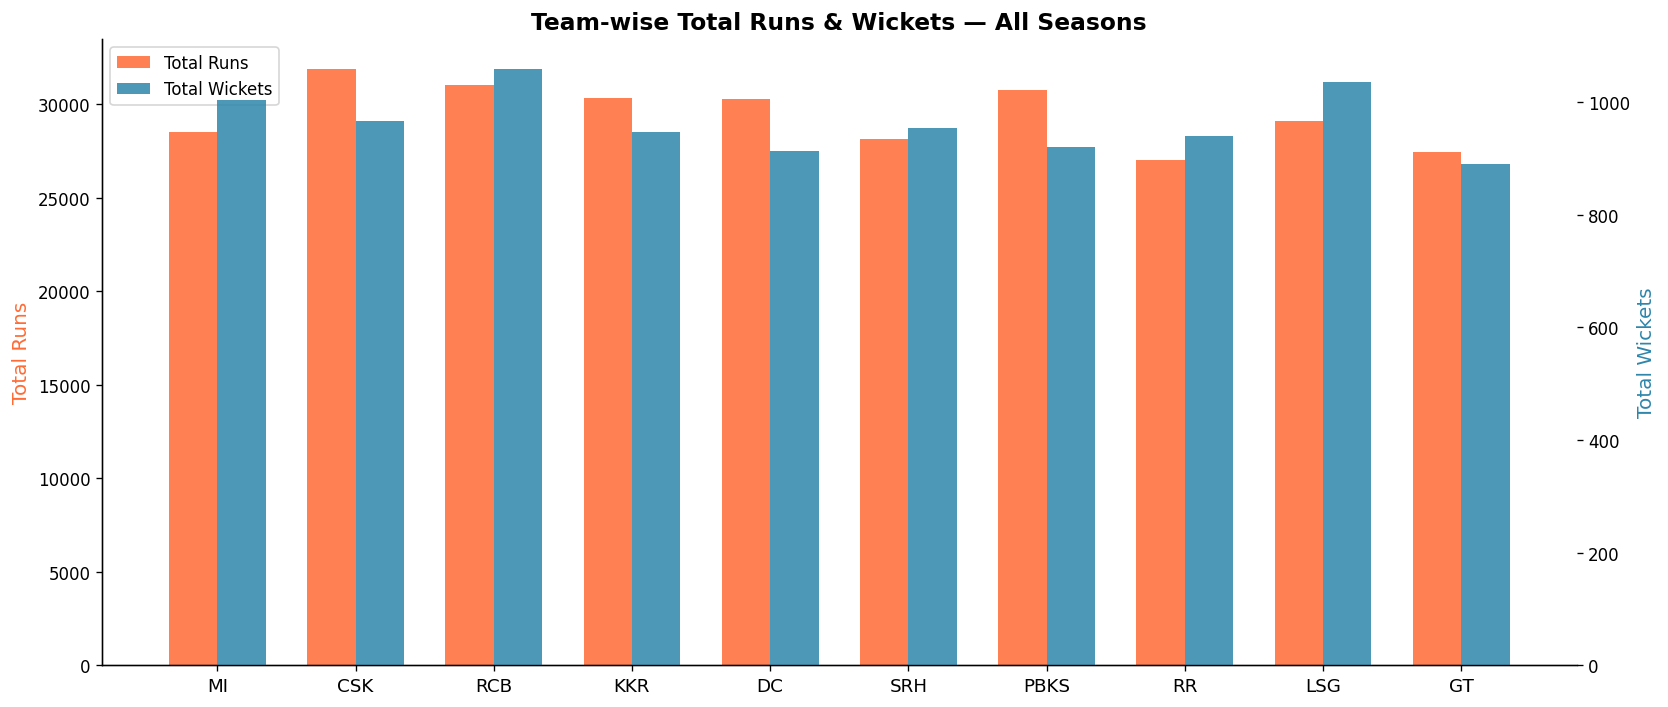

In [7]:
team_batting  = batting.groupby('Team')['Runs'].sum()
team_wickets  = bowling.groupby('Team')['Wickets'].sum()

x = np.arange(len(teams))
w = 0.35

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - w/2, [team_batting[t] for t in teams],
                w, label='Total Runs', color='#FF6B35', alpha=0.85)
bars2 = ax2.bar(x + w/2, [team_wickets[t] for t in teams],
                w, label='Total Wickets', color='#2E86AB', alpha=0.85)

ax1.set_ylabel('Total Runs', color='#FF6B35', fontsize=12)
ax2.set_ylabel('Total Wickets', color='#2E86AB', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(teams, fontsize=11)
ax1.set_title('Team-wise Total Runs & Wickets — All Seasons', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('ipl_team_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

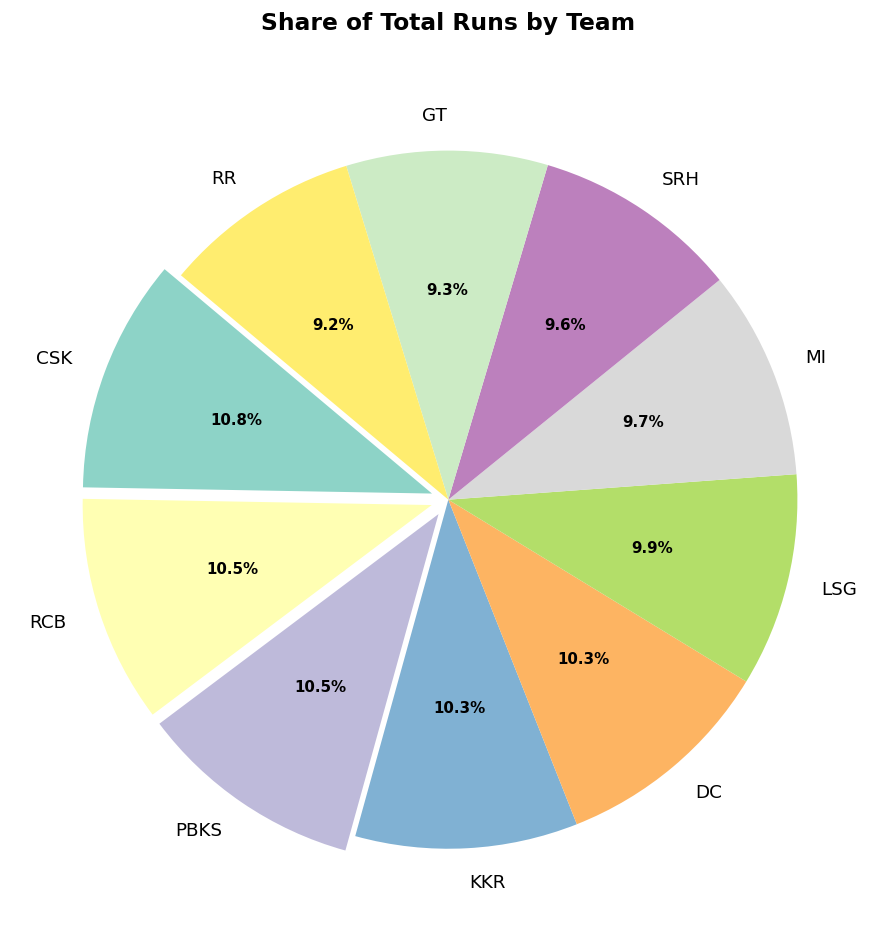

In [8]:
team_runs = batting.groupby('Team')['Runs'].sum().sort_values(ascending=False)

explode = [0.05 if i < 3 else 0 for i in range(len(team_runs))]
colors  = plt.cm.Set3(np.linspace(0, 1, len(team_runs)))

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    team_runs.values, labels=team_runs.index,
    autopct='%1.1f%%', explode=explode,
    colors=colors, startangle=140,
    textprops={'fontsize': 11})

for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax.set_title('Share of Total Runs by Team', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('ipl_team_pie.png', dpi=150, bbox_inches='tight')
plt.show()

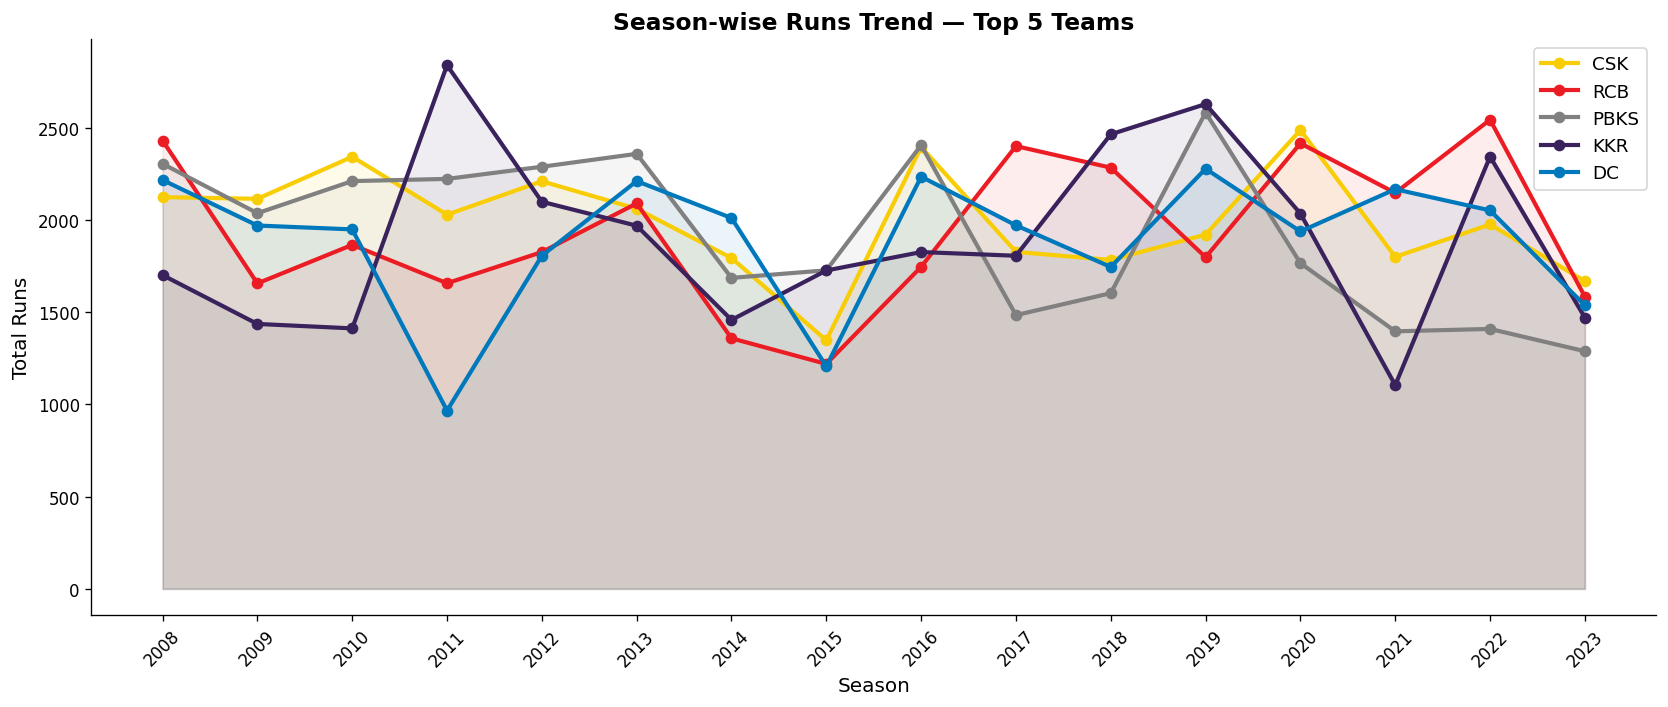

In [9]:
top5_teams = batting.groupby('Team')['Runs'].sum().nlargest(5).index
season_team = batting[batting['Team'].isin(top5_teams)]\
              .groupby(['Season','Team'])['Runs'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
colors_map = {'MI':'#004BA0','CSK':'#F9CD05','RCB':'#EC1C24',
              'KKR':'#3A225D','DC':'#0078BC'}

for team in top5_teams:
    d = season_team[season_team['Team']==team]
    ax.plot(d['Season'], d['Runs'], marker='o', linewidth=2.5,
            label=team, color=colors_map.get(team,'gray'))
    ax.fill_between(d['Season'], d['Runs'], alpha=0.08,
                    color=colors_map.get(team,'gray'))

ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Total Runs', fontsize=12)
ax.set_title('Season-wise Runs Trend — Top 5 Teams', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(seasons)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ipl_season_trend.png', dpi=150, bbox_inches='tight')
plt.show()

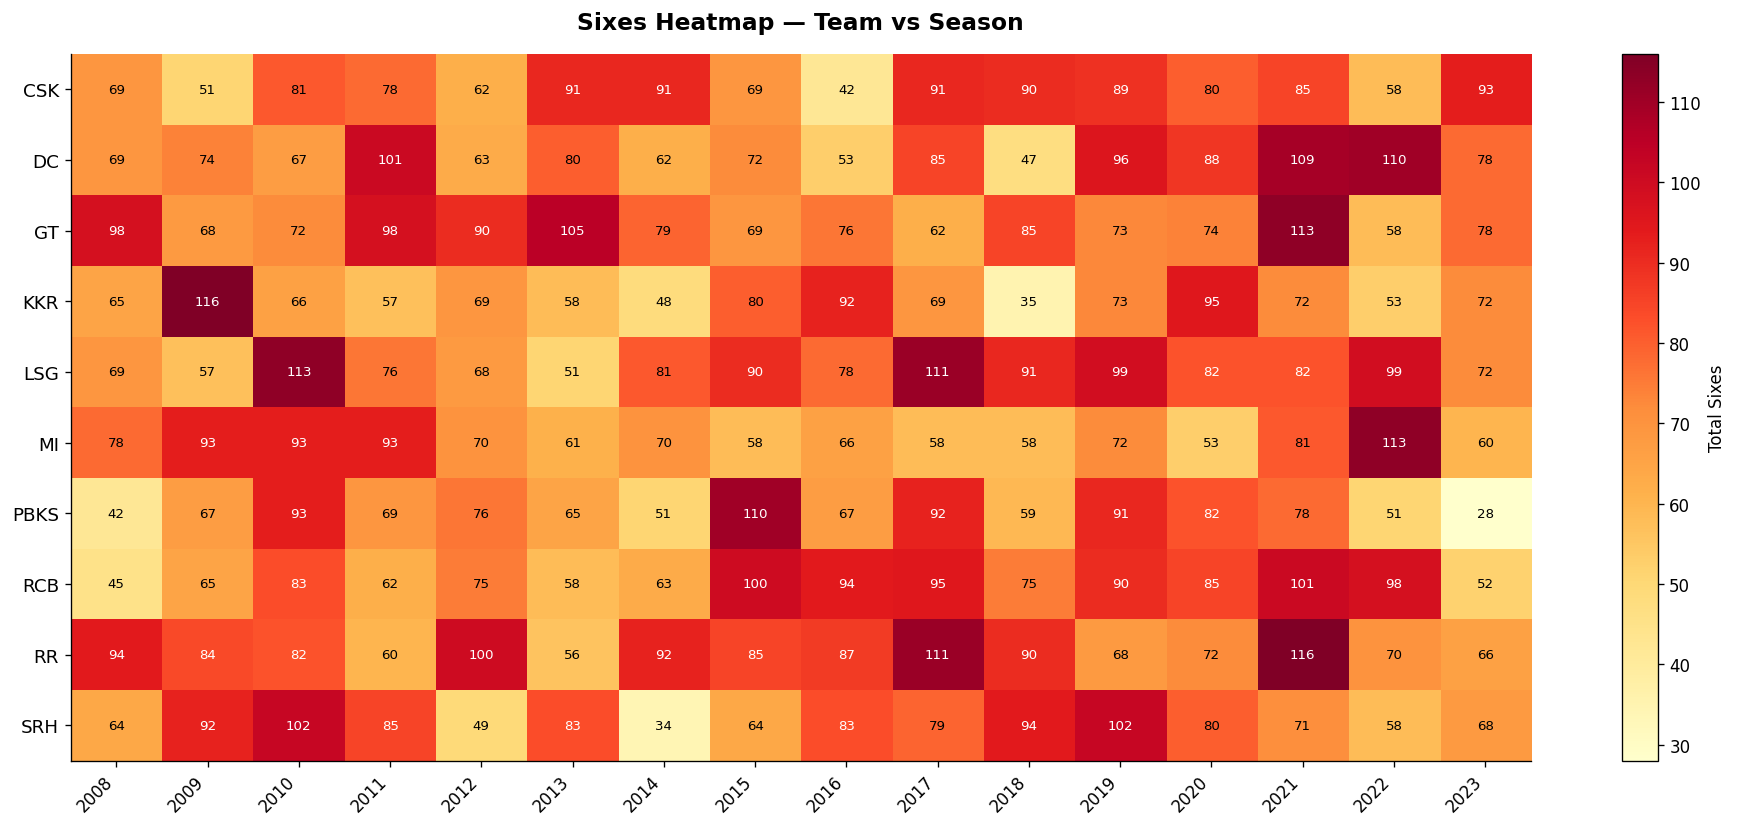

In [10]:
pivot = batting.groupby(['Team','Season'])['Sixes'].sum().unstack()

fig, ax = plt.subplots(figsize=(16, 7))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, str(int(pivot.values[i,j])),
                ha='center', va='center', fontsize=8,
                color='black' if pivot.values[i,j] < pivot.values.max()*0.7 else 'white')

plt.colorbar(im, label='Total Sixes')
ax.set_title('Sixes Heatmap — Team vs Season', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('ipl_sixes_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

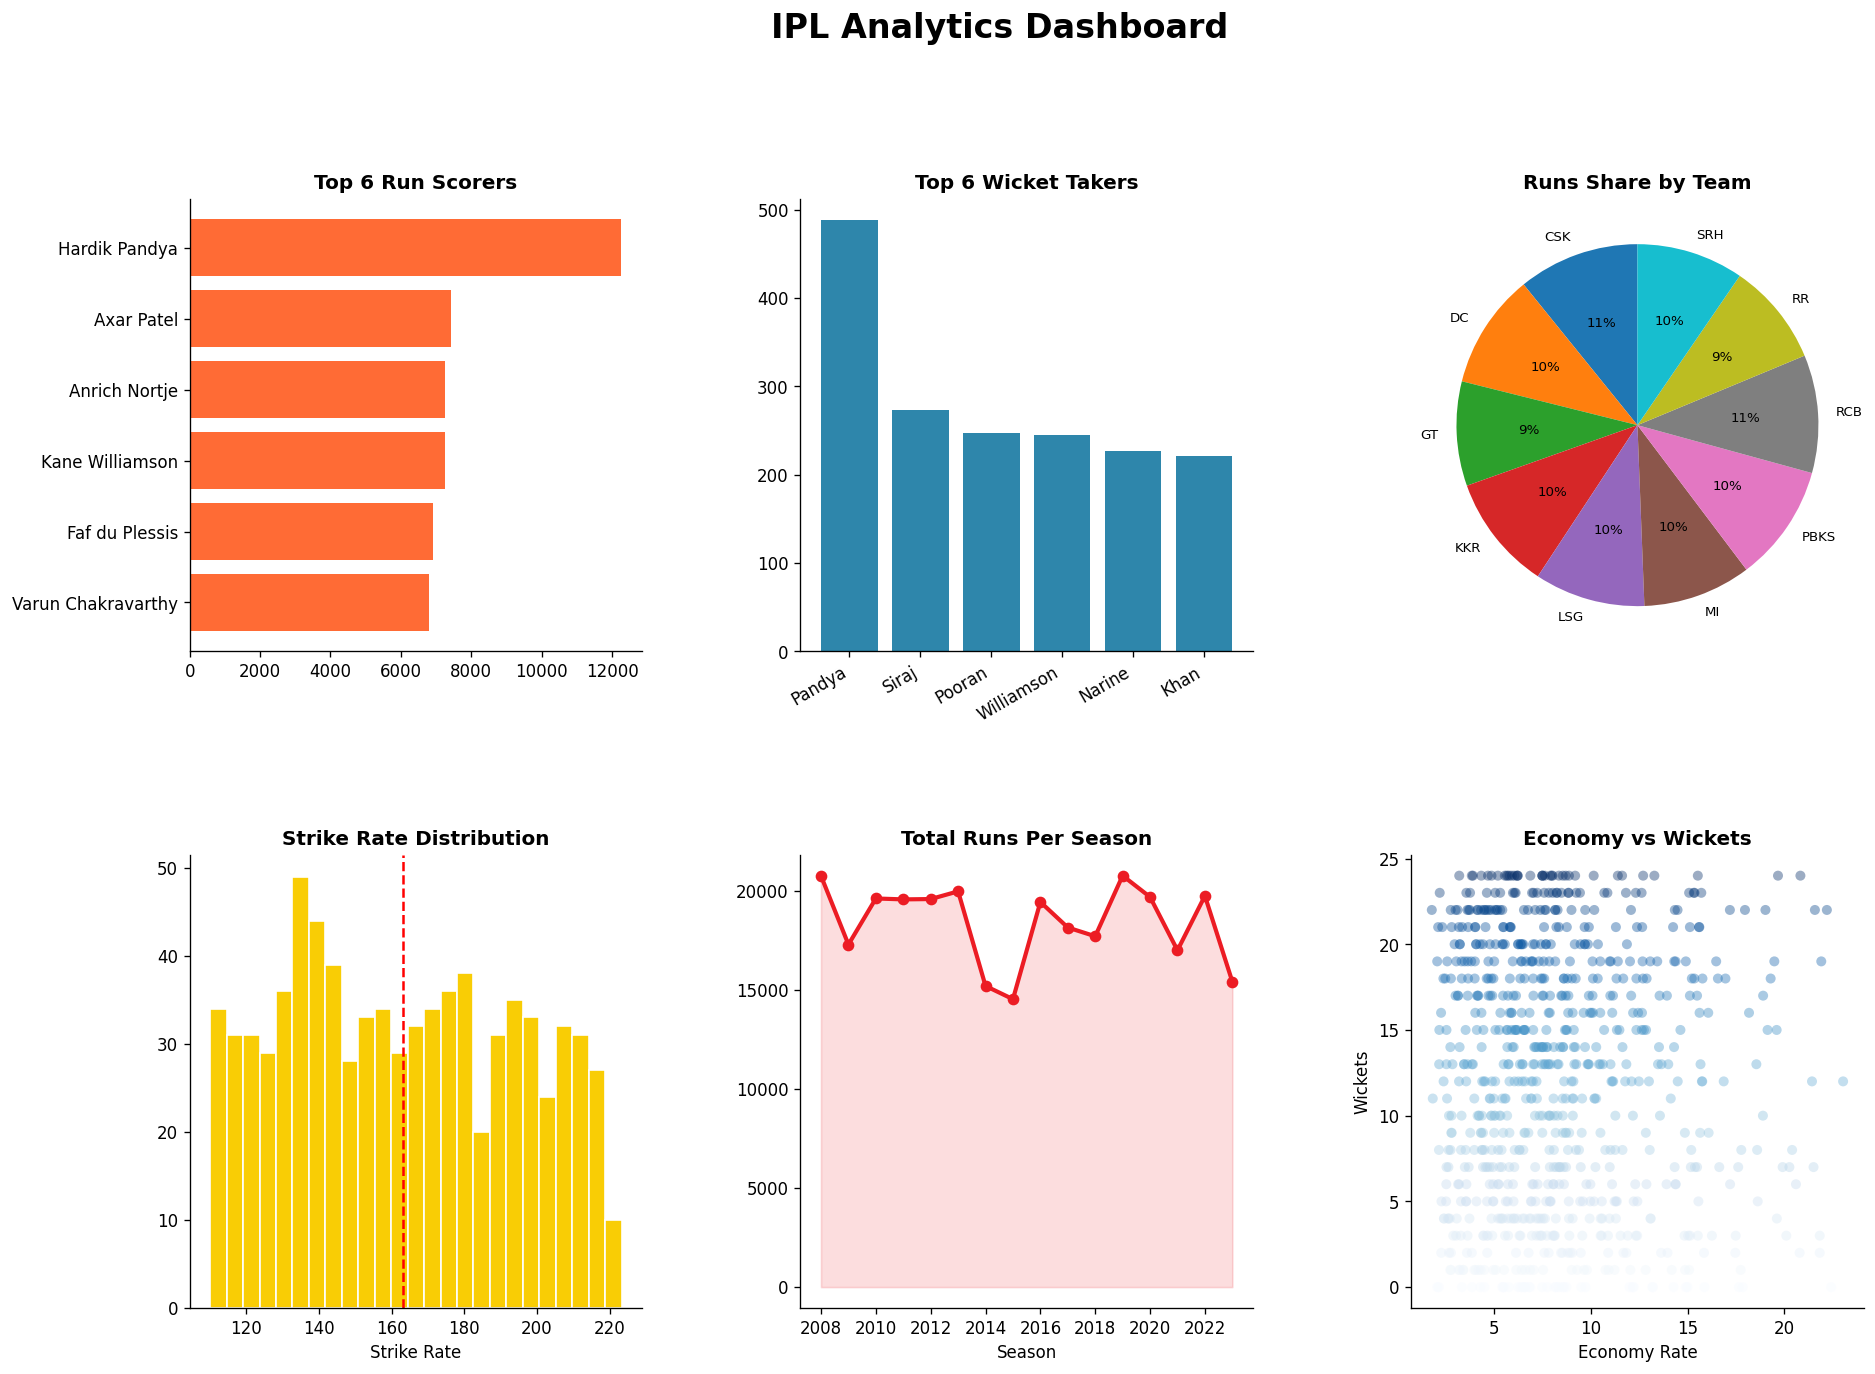

Master dashboard saved!


In [12]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('IPL Analytics Dashboard', fontsize=20, fontweight='bold', y=1.01)
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
tb = batting.groupby('Player')['Runs'].sum().nlargest(6)
ax1.barh(tb.index, tb.values, color='#FF6B35')
ax1.set_title('Top 6 Run Scorers', fontweight='bold')
ax1.invert_yaxis()

ax2 = fig.add_subplot(gs[0, 1])
tbw = bowling.groupby('Player')['Wickets'].sum().nlargest(6)
ax2.bar(range(6), tbw.values, color='#2E86AB')
ax2.set_xticks(range(6))
ax2.set_xticklabels([n.split()[-1] for n in tbw.index], rotation=30, ha='right')
ax2.set_title('Top 6 Wicket Takers', fontweight='bold')

ax3 = fig.add_subplot(gs[0, 2])
tr = batting.groupby('Team')['Runs'].sum()
ax3.pie(tr.values, labels=tr.index, autopct='%1.0f%%',
        textprops={'fontsize':8}, startangle=90)
ax3.set_title('Runs Share by Team', fontweight='bold')

ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(batting['Strike Rate'], bins=25, color='#F9CD05', edgecolor='white')
ax4.axvline(batting['Strike Rate'].mean(), color='red', linestyle='--')
ax4.set_title('Strike Rate Distribution', fontweight='bold')
ax4.set_xlabel('Strike Rate')

ax5 = fig.add_subplot(gs[1, 1])
season_runs = batting.groupby('Season')['Runs'].sum()
ax5.plot(season_runs.index, season_runs.values,
         marker='o', color='#EC1C24', linewidth=2.5)
ax5.fill_between(season_runs.index, season_runs.values, alpha=0.15, color='#EC1C24')
ax5.set_title('Total Runs Per Season', fontweight='bold')
ax5.set_xlabel('Season')

ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(bowling['Economy'], bowling['Wickets'],
            alpha=0.4, c=bowling['Wickets'], cmap='Blues', edgecolors='none')
ax6.set_xlabel('Economy Rate')
ax6.set_ylabel('Wickets')
ax6.set_title('Economy vs Wickets', fontweight='bold')

plt.savefig('ipl_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Master dashboard saved!")

In [13]:
batting.to_csv('ipl_batting_stats.csv', index=False)
bowling.to_csv('ipl_bowling_stats.csv', index=False)

team_summary = pd.DataFrame({
    'Team': teams,
    'Total_Runs':    [batting[batting['Team']==t]['Runs'].sum() for t in teams],
    'Total_Wickets': [bowling[bowling['Team']==t]['Wickets'].sum() for t in teams],
    'Total_Sixes':   [batting[batting['Team']==t]['Sixes'].sum() for t in teams],
    'Avg_SR':        [batting[batting['Team']==t]['Strike Rate'].mean().round(2) for t in teams],
    'Avg_Economy':   [bowling[bowling['Team']==t]['Economy'].mean().round(2) for t in teams],
})
team_summary.to_csv('ipl_team_summary.csv', index=False)
print("All CSVs exported!")
print(team_summary)

All CSVs exported!
   Team  Total_Runs  Total_Wickets  Total_Sixes  Avg_SR  Avg_Economy
0    MI       28498           1004         1177  160.69         8.19
1   CSK       31898            966         1220  164.20         8.52
2   RCB       31038           1059         1241  165.47         8.40
3   KKR       30336            947         1120  157.20         7.93
4    DC       30275            914         1254  164.72         7.86
5   SRH       28168            954         1208  169.14         8.87
6  PBKS       30788            920         1121  161.22         8.03
7    RR       27001            940         1333  161.16         8.70
8   LSG       29126           1036         1319  162.32         8.03
9    GT       27471            890         1298  166.16         8.37


In [14]:
from google.colab import files
for f in ['ipl_batting_stats.csv','ipl_bowling_stats.csv',
          'ipl_team_summary.csv','ipl_top_batters.png',
          'ipl_top_bowlers.png','ipl_sr_vs_avg.png',
          'ipl_economy_dist.png','ipl_team_comparison.png',
          'ipl_team_pie.png','ipl_season_trend.png',
          'ipl_sixes_heatmap.png','ipl_dashboard.png']:
    files.download(f)
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
